<a href="https://colab.research.google.com/github/allanjfarias/PISI3/blob/main/notebooks/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicação Random Forest

Import de bibliotecas

In [14]:
!pip install imbalanced-learn
!pip install shap

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import cross_val_score
import shap

Load do DF

In [16]:
df = pd.read_csv("../datasets/spotify_processed.csv")

Random Forest

In [17]:
# Carregar os dados (substitua 'df' pelo seu DataFrame real)
new_df = df.copy()

# Separar features (X) e target (y)
X = new_df.drop(columns=['is_popular'])  # Features
y = new_df['is_popular']                # Target

Matriz de Confusão:
[[13523  8225]
 [  799  1857]]


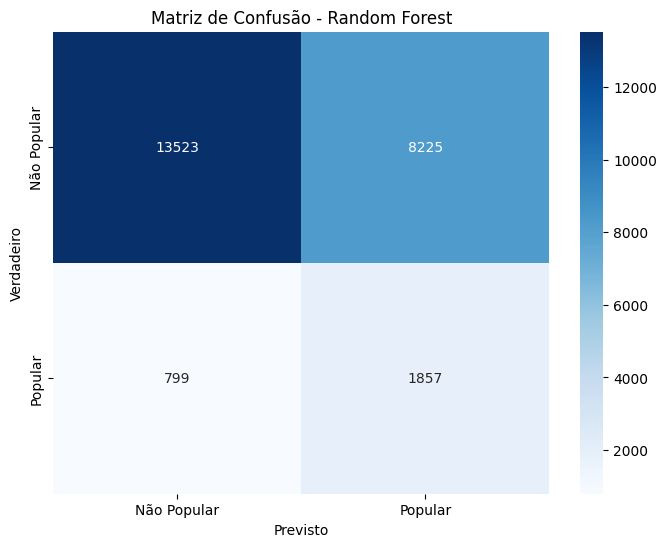


Métricas de Classificação:
              precision    recall  f1-score   support

 Não Popular       0.94      0.62      0.75     21748
     Popular       0.18      0.70      0.29      2656

    accuracy                           0.63     24404
   macro avg       0.56      0.66      0.52     24404
weighted avg       0.86      0.63      0.70     24404



C:\Users\Luan D' Miranda\AppData\Local\Temp\ipykernel_5016\3809946691.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias[indices_ordenados], y=nomes_variaveis[indices_ordenados], palette='viridis')


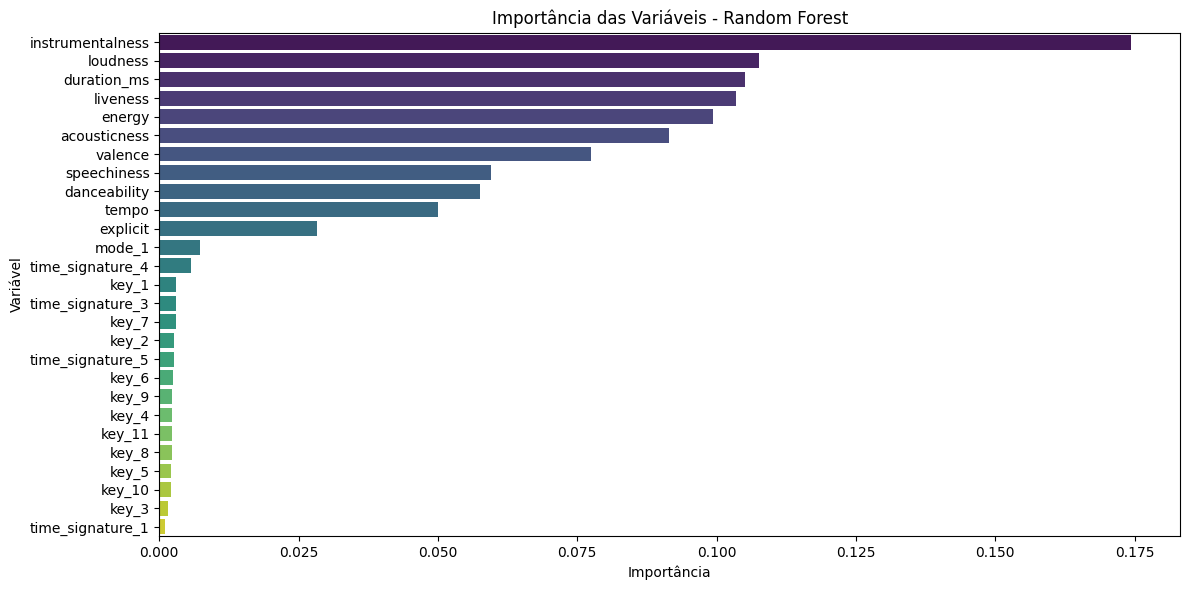

In [18]:
# Dividir dados em treino e teste (30% para teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Definir o modelo com hyperparâmetros de regularização
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,               # Limita a profundidade das árvores
    min_samples_split=10,       # Evita divisões em nós com poucas amostras
    min_samples_leaf=2,         # Garante folhas com mais amostras
    max_features='sqrt',        # Usa sqrt(n_features) em cada divisão
    class_weight='balanced',    # Balanceia classes desiguais
    random_state=42
)

# Treinar o modelo
model.fit(X_train, y_train)

# Previsões e avaliação
y_pred = model.predict(X_test)

# Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

# Relatório de Classificação
print("\nMétricas de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Não Popular', 'Popular']))

# Importância das Variáveis (para feature selection)
importancias = model.feature_importances_
nomes_variaveis = X.columns

# Ordenar por importância
indices_ordenados = np.argsort(importancias)[::-1]
plt.figure(figsize=(12, 6))
sns.barplot(x=importancias[indices_ordenados], y=nomes_variaveis[indices_ordenados], palette='viridis')
plt.title('Importância das Variáveis - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

Avaliação do conjunto de treino

Matriz de Confusão para o conjunto de treino:
[[31735 19027]
 [ 1174  5004]]


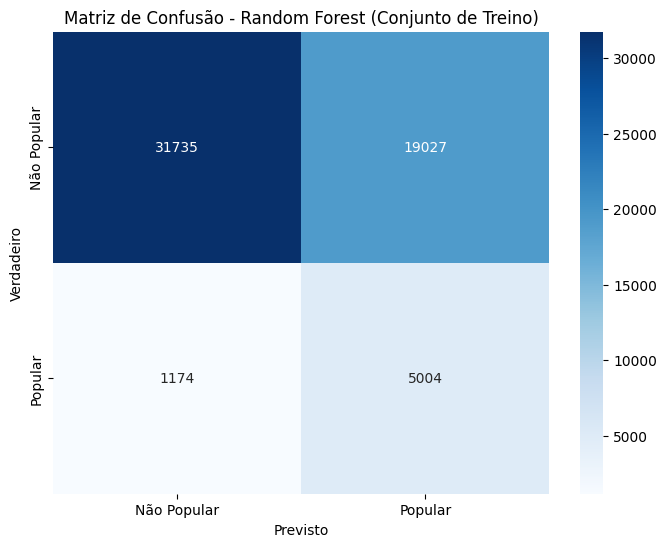


Métricas de Classificação para o conjunto de treino:
              precision    recall  f1-score   support

 Não Popular       0.96      0.63      0.76     50762
     Popular       0.21      0.81      0.33      6178

    accuracy                           0.65     56940
   macro avg       0.59      0.72      0.54     56940
weighted avg       0.88      0.65      0.71     56940



In [19]:
# Previsões no conjunto de treino
y_train_pred = model.predict(X_train)

# Matriz de Confusão para o conjunto de treino
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
print("Matriz de Confusão para o conjunto de treino:")
print(conf_matrix_train)

# Plotar a matriz de confusão para o conjunto de treino
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Popular', 'Popular'],
            yticklabels=['Não Popular', 'Popular'])
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - Random Forest (Conjunto de Treino)')
plt.show()

# Relatório de classificação para o conjunto de treino
print("\nMétricas de Classificação para o conjunto de treino:")
print(classification_report(y_train, y_train_pred, target_names=['Não Popular', 'Popular']))

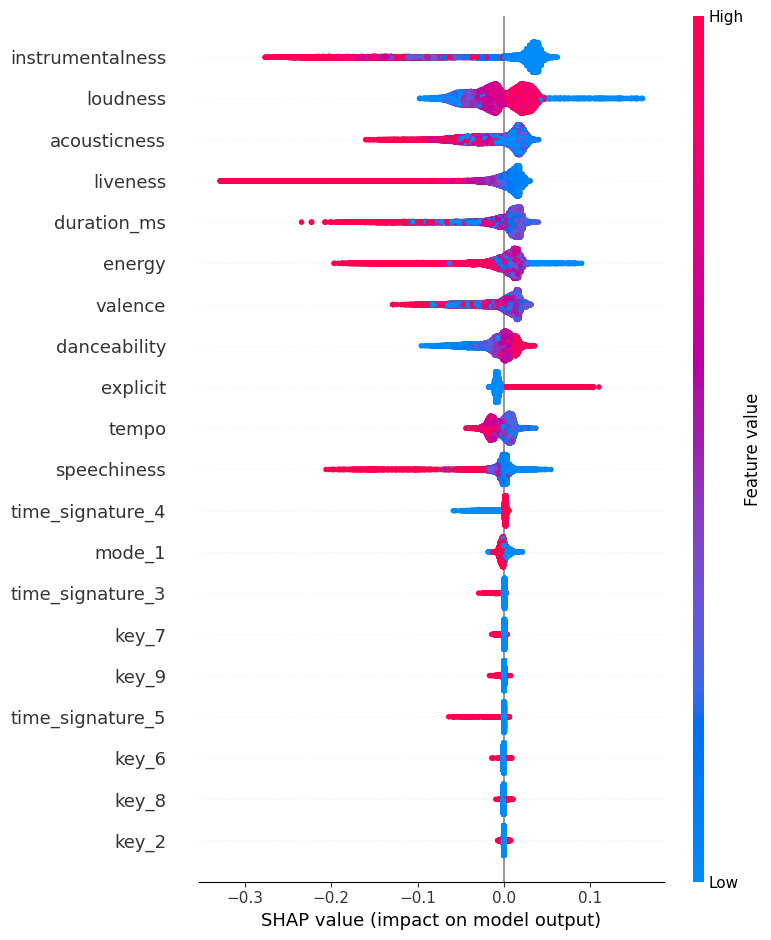

In [22]:
# Gerar valores SHAP para o modelo Random Forest
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Gráfico summary plot para a classe 1 (Popular)
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X_test.columns)

Cross Validation

In [23]:
# Cross-validation para avaliar overfitting no modelo Random Forest
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Acurácias de cross-validation:", cv_scores)
print("Média da acurácia de cross-validation:", np.mean(cv_scores))

# Calcular acurácia no treino e teste
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print("Acurácia no treino:", train_acc)
print("Acurácia no teste:", test_acc)

Acurácias de cross-validation: [0.63145416 0.62925887 0.62284861 0.63233228 0.63083948]
Média da acurácia de cross-validation: 0.6293466807165438
Acurácia no treino: 0.6452230417983843
Acurácia no teste: 0.6302245533519095
